# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abbas829/mental-health-in-tech-survey-20142025/mental_health_survey.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/abbas829/mental-health-in-tech-survey-20142025/mental_health_survey.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


## last Five row

In [4]:
df.tail()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN
1258,2016-02-01 23:04:31,25,Male,United States,IL,No,Yes,Yes,Sometimes,26-100,...,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No,NaN


## Shape of our dataset

In [5]:
df.shape

(1259, 27)

## List out all columns

In [6]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

## Check Null Value

In [9]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

# Drop Null Value Features

In [10]:
df.drop(columns=['state', 'work_interfere', 'comments', 'self_employed'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

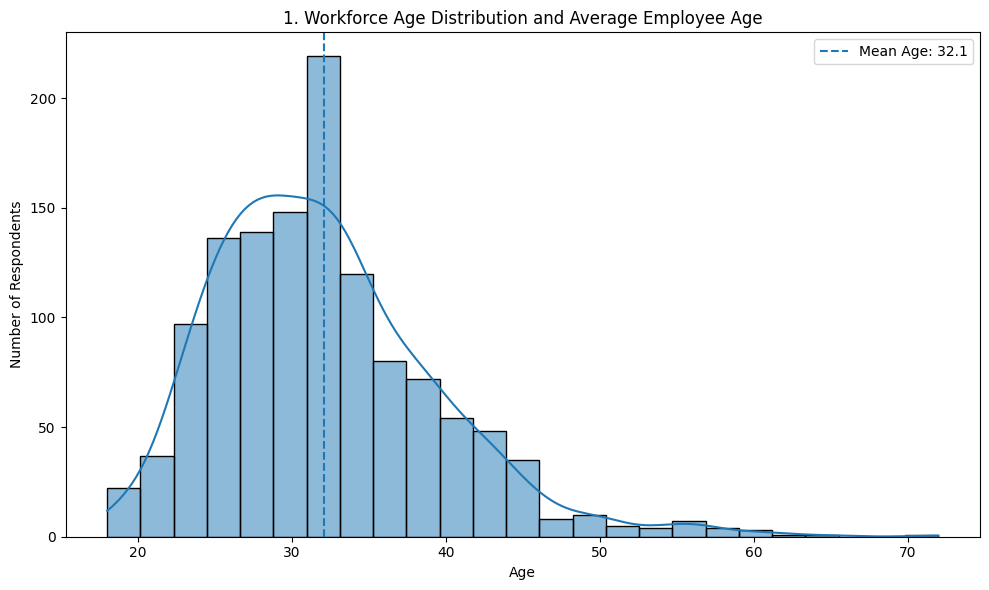

In [14]:
fig = plt.figure(figsize=(10,6))
age_data = df.loc[df['Age'].between(18, 75), 'Age'].dropna()
sns.histplot(age_data, bins=25, kde=True)
plt.axvline(age_data.mean(), linestyle='--', label=f'Mean Age: {age_data.mean():.1f}')
plt.title(f'{plot_no}. Workforce Age Distribution and Average Employee Age')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.legend()
show_fig()
plot_no += 1

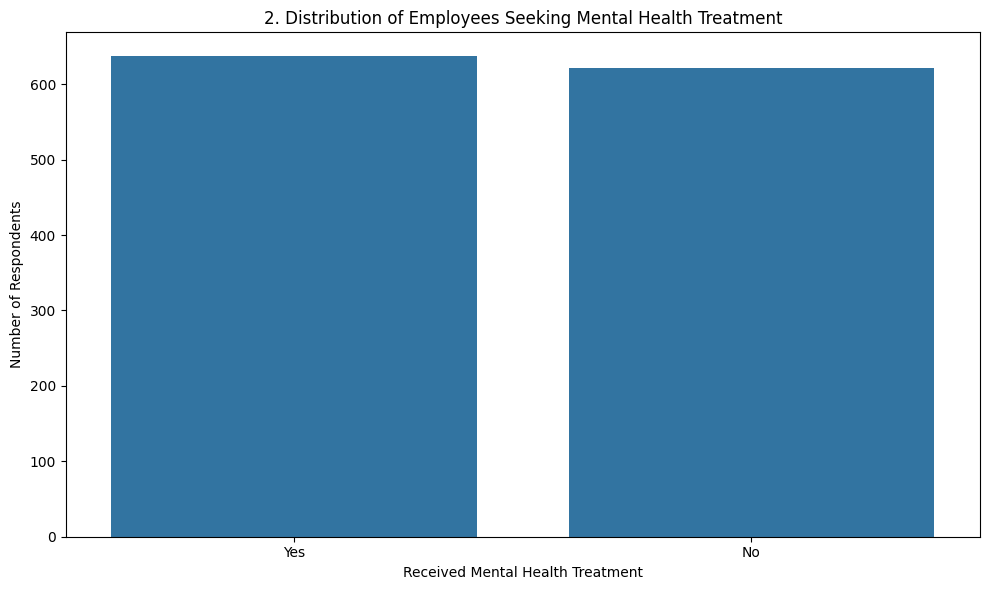

In [15]:
fig = plt.figure(figsize=(10,6))
treatment_counts = df['treatment'].value_counts().reset_index()
treatment_counts.columns = ['Treatment', 'Respondents']
sns.barplot(data=treatment_counts, x='Treatment', y='Respondents')
plt.title(f'{plot_no}. Distribution of Employees Seeking Mental Health Treatment')
plt.xlabel('Received Mental Health Treatment')
plt.ylabel('Number of Respondents')
show_fig()
plot_no += 1

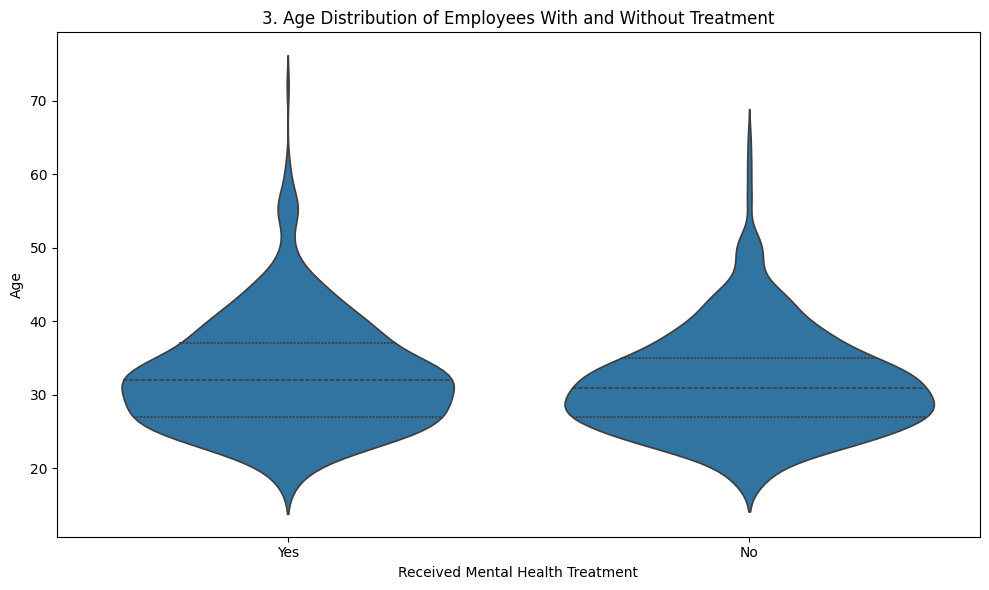

In [16]:
fig = plt.figure(figsize=(10,6))
age_treatment = df[df['Age'].between(18, 75)].dropna(subset=['Age', 'treatment'])
sns.violinplot(data=age_treatment, x='treatment', y='Age', inner='quartile')
plt.title(f'{plot_no}. Age Distribution of Employees With and Without Treatment')
plt.xlabel('Received Mental Health Treatment')
plt.ylabel('Age')
show_fig()
plot_no += 1

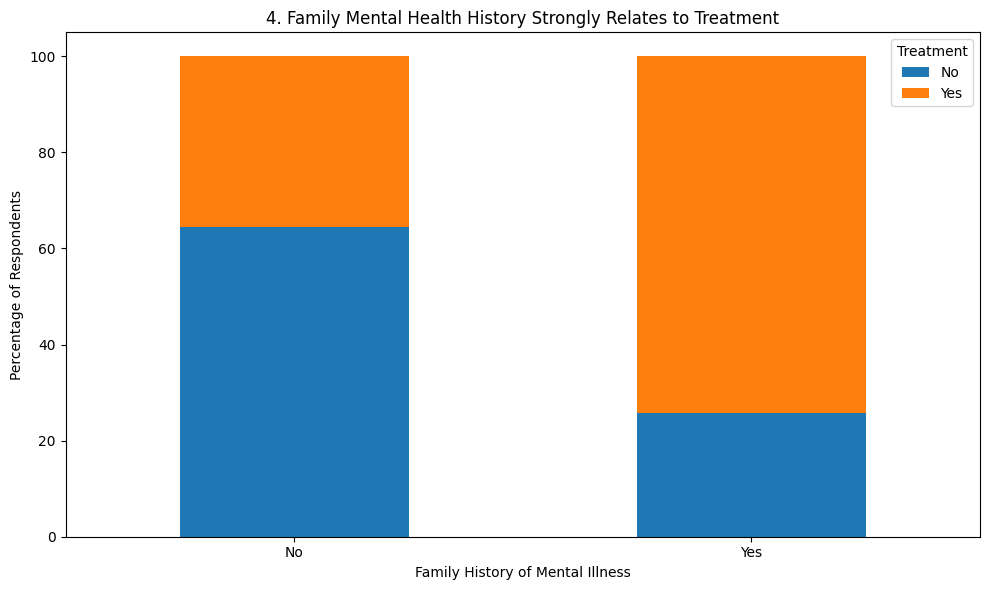

In [17]:
fig = plt.figure(figsize=(10,6))
family_treatment = pd.crosstab(
    df['family_history'],
    df['treatment'],
    normalize='index'
).mul(100)
family_treatment.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Family Mental Health History Strongly Relates to Treatment')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
show_fig()
plot_no += 1

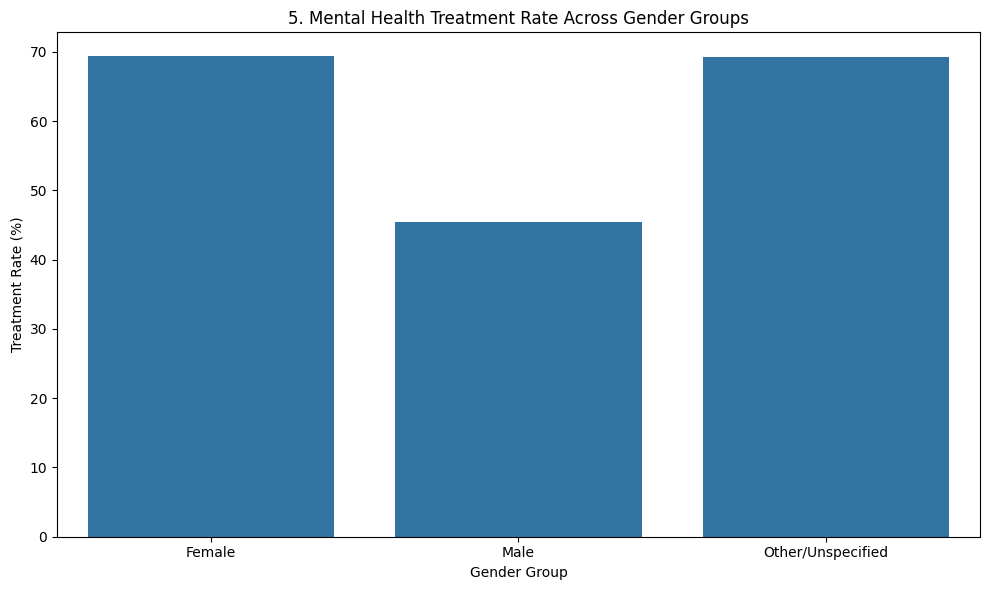

In [18]:
fig = plt.figure(figsize=(10,6))
gender_clean = df['Gender'].astype(str).str.strip().str.lower()
gender_clean = gender_clean.apply(
    lambda value: 'Female'
    if 'female' in value or value in ['f', 'woman', 'cis woman']
    else 'Male'
    if (('male' in value and 'female' not in value) or value in ['m', 'man', 'cis man'])
    else 'Other/Unspecified'
)
gender_analysis = pd.DataFrame({
    'Gender Group': gender_clean,
    'Treatment': df['treatment'].eq('Yes').astype(int)
})
gender_summary = gender_analysis.groupby('Gender Group').agg(
    Treatment_Rate=('Treatment', 'mean'),
    Respondents=('Treatment', 'size')
).reset_index()
gender_summary = gender_summary[gender_summary['Respondents'] >= 10]
gender_summary['Treatment Rate'] = gender_summary['Treatment_Rate'] * 100
sns.barplot(data=gender_summary, x='Gender Group', y='Treatment Rate')
plt.title(f'{plot_no}. Mental Health Treatment Rate Across Gender Groups')
plt.xlabel('Gender Group')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

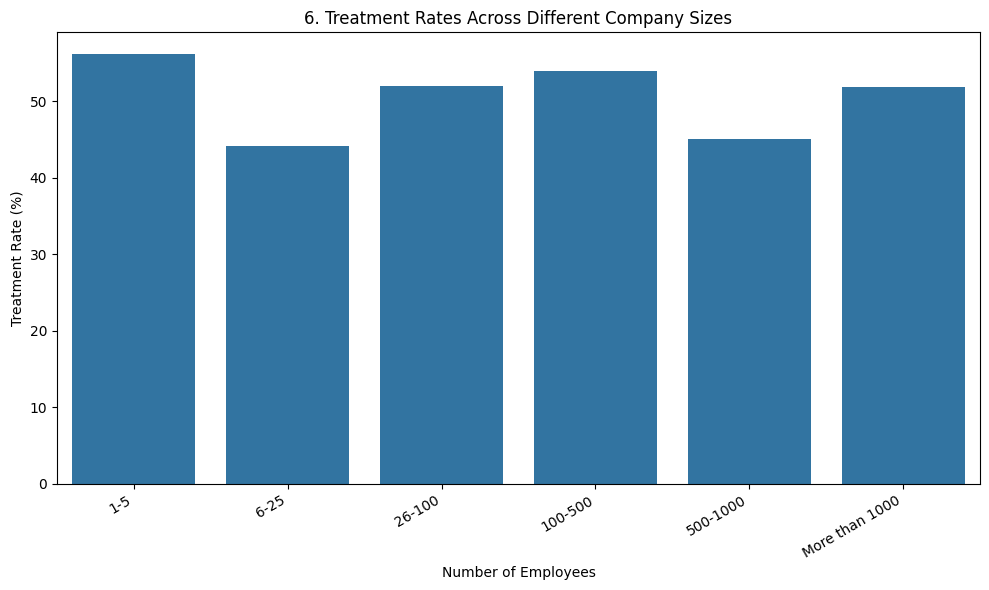

In [19]:
fig = plt.figure(figsize=(10,6))
employee_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
company_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('no_employees', as_index=False)['Treatment_Rate'].mean()
company_treatment['Treatment_Rate'] *= 100
sns.barplot(
    data=company_treatment,
    x='no_employees',
    y='Treatment_Rate',
    order=employee_order
)
plt.title(f'{plot_no}. Treatment Rates Across Different Company Sizes')
plt.xlabel('Number of Employees')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

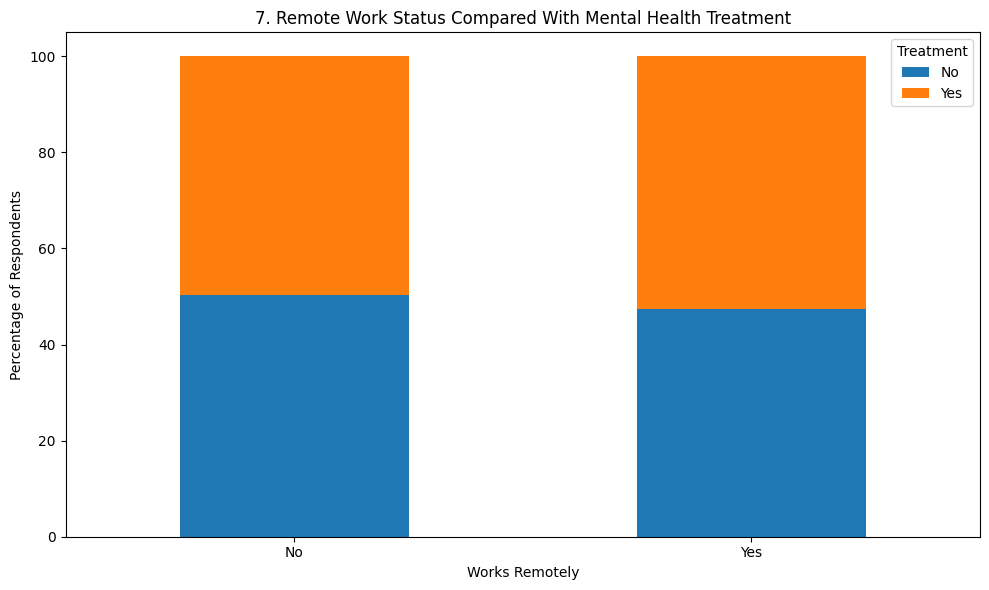

In [20]:
fig = plt.figure(figsize=(10,6))
remote_treatment = pd.crosstab(
    df['remote_work'],
    df['treatment'],
    normalize='index'
).mul(100)
remote_treatment.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Remote Work Status Compared With Mental Health Treatment')
plt.xlabel('Works Remotely')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
show_fig()
plot_no += 1

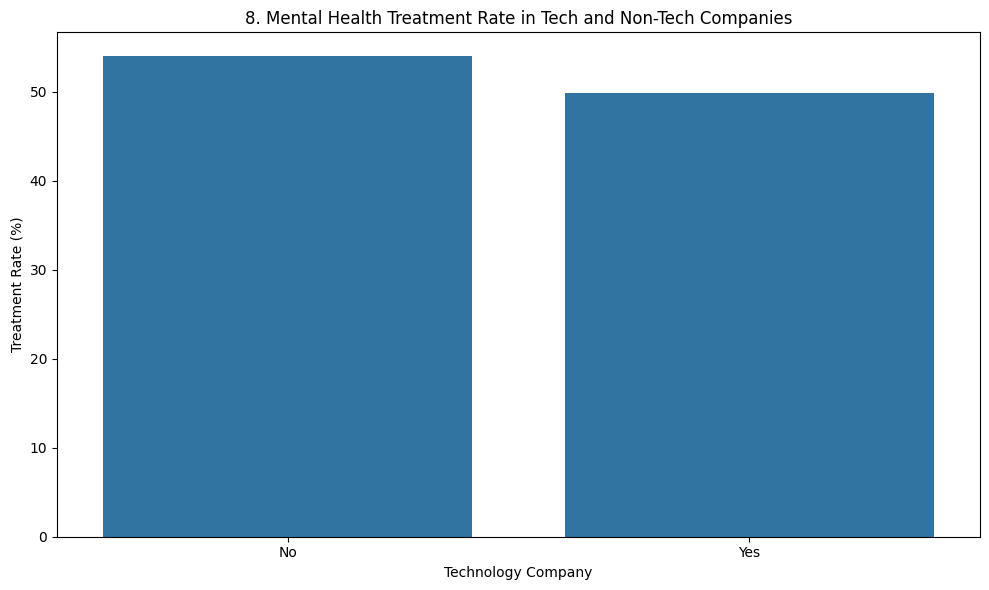

In [21]:
fig = plt.figure(figsize=(10,6))
tech_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('tech_company', as_index=False)['Treatment_Rate'].mean()
tech_treatment['Treatment_Rate'] *= 100
sns.barplot(data=tech_treatment, x='tech_company', y='Treatment_Rate')
plt.title(f'{plot_no}. Mental Health Treatment Rate in Tech and Non-Tech Companies')
plt.xlabel('Technology Company')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

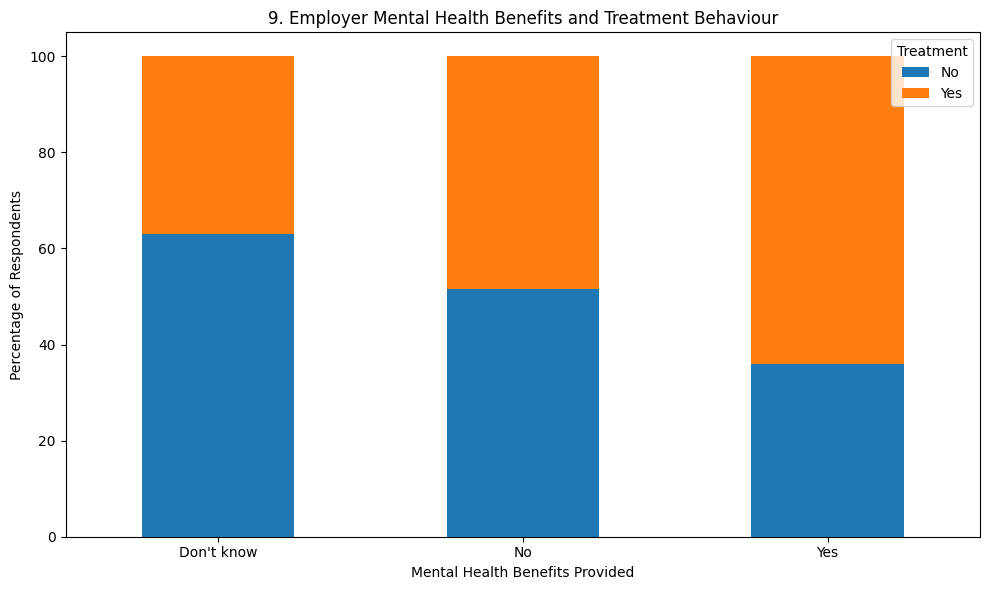

In [22]:
fig = plt.figure(figsize=(10,6))
benefits_treatment = pd.crosstab(
    df['benefits'],
    df['treatment'],
    normalize='index'
).mul(100)
benefits_treatment.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Employer Mental Health Benefits and Treatment Behaviour')
plt.xlabel('Mental Health Benefits Provided')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
show_fig()
plot_no += 1

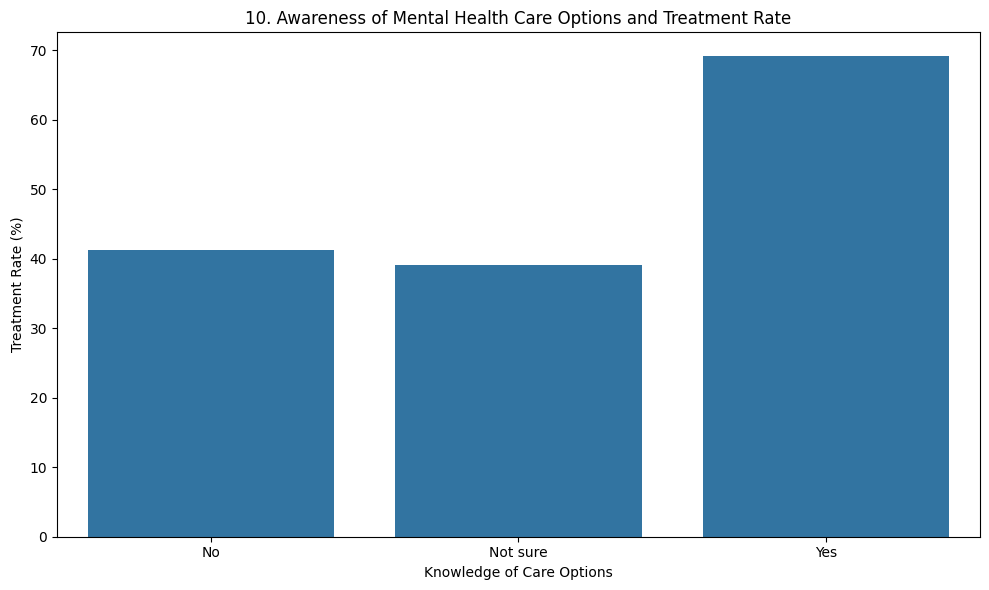

In [23]:
fig = plt.figure(figsize=(10,6))
care_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('care_options', as_index=False)['Treatment_Rate'].mean()
care_treatment['Treatment_Rate'] *= 100
sns.barplot(data=care_treatment, x='care_options', y='Treatment_Rate')
plt.title(f'{plot_no}. Awareness of Mental Health Care Options and Treatment Rate')
plt.xlabel('Knowledge of Care Options')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

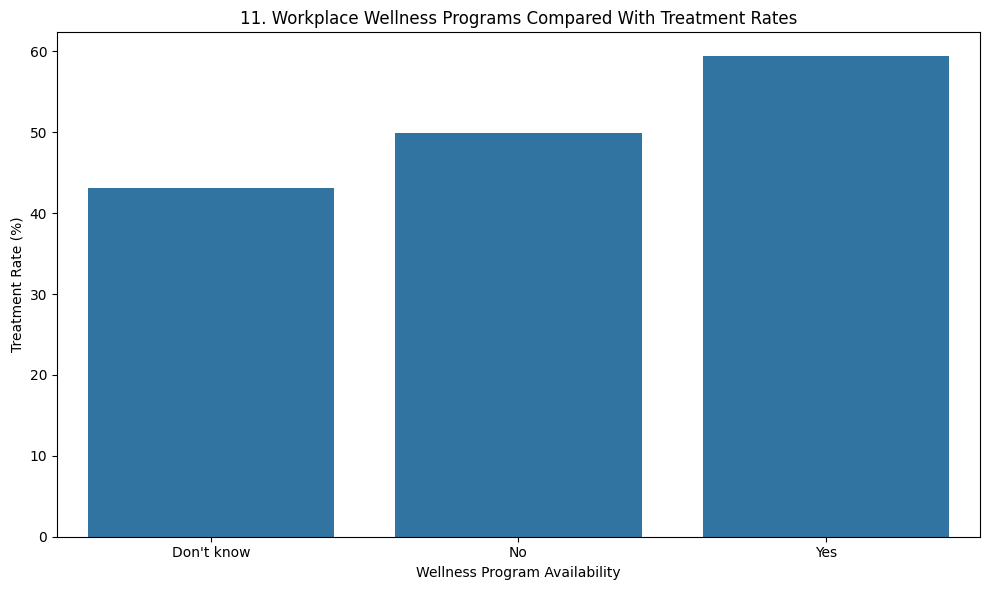

In [24]:
fig = plt.figure(figsize=(10,6))
wellness_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('wellness_program', as_index=False)['Treatment_Rate'].mean()
wellness_treatment['Treatment_Rate'] *= 100
sns.barplot(data=wellness_treatment, x='wellness_program', y='Treatment_Rate')
plt.title(f'{plot_no}. Workplace Wellness Programs Compared With Treatment Rates')
plt.xlabel('Wellness Program Availability')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

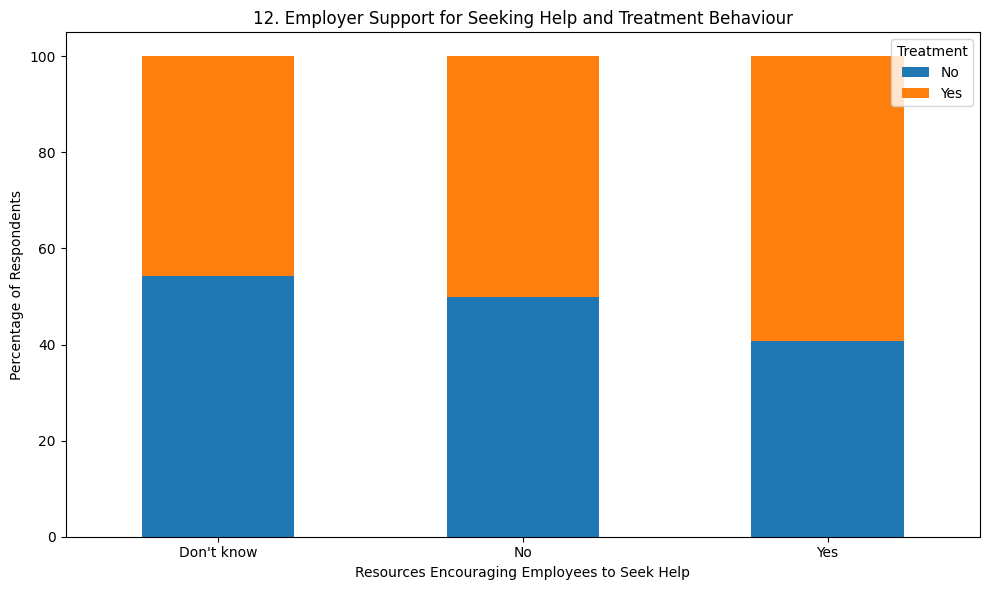

In [25]:
fig = plt.figure(figsize=(10,6))
help_treatment = pd.crosstab(
    df['seek_help'],
    df['treatment'],
    normalize='index'
).mul(100)
help_treatment.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Employer Support for Seeking Help and Treatment Behaviour')
plt.xlabel('Resources Encouraging Employees to Seek Help')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
show_fig()
plot_no += 1

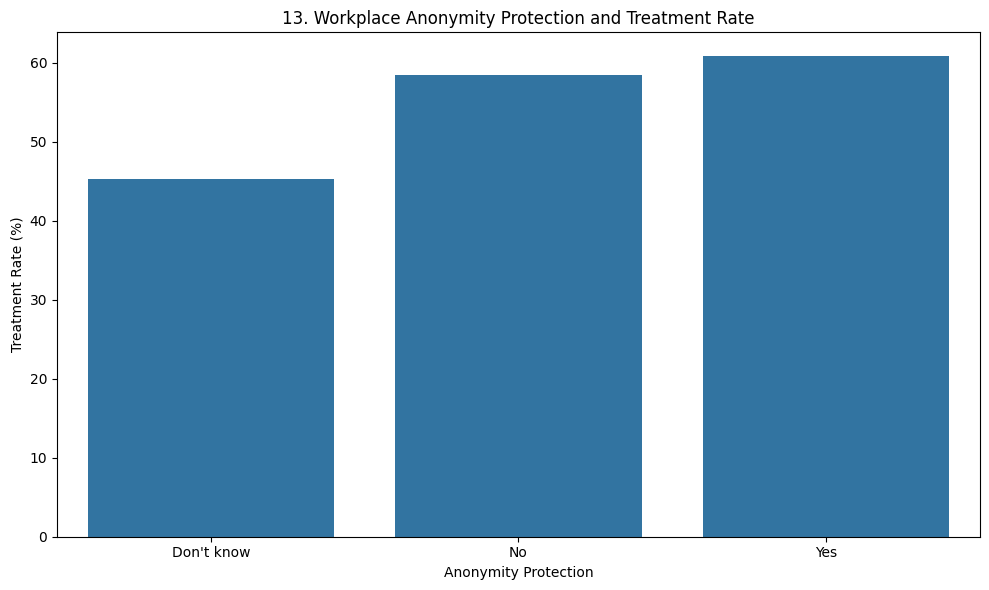

In [26]:
fig = plt.figure(figsize=(10,6))
anonymity_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('anonymity', as_index=False)['Treatment_Rate'].mean()
anonymity_treatment['Treatment_Rate'] *= 100
sns.barplot(data=anonymity_treatment, x='anonymity', y='Treatment_Rate')
plt.title(f'{plot_no}. Workplace Anonymity Protection and Treatment Rate')
plt.xlabel('Anonymity Protection')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

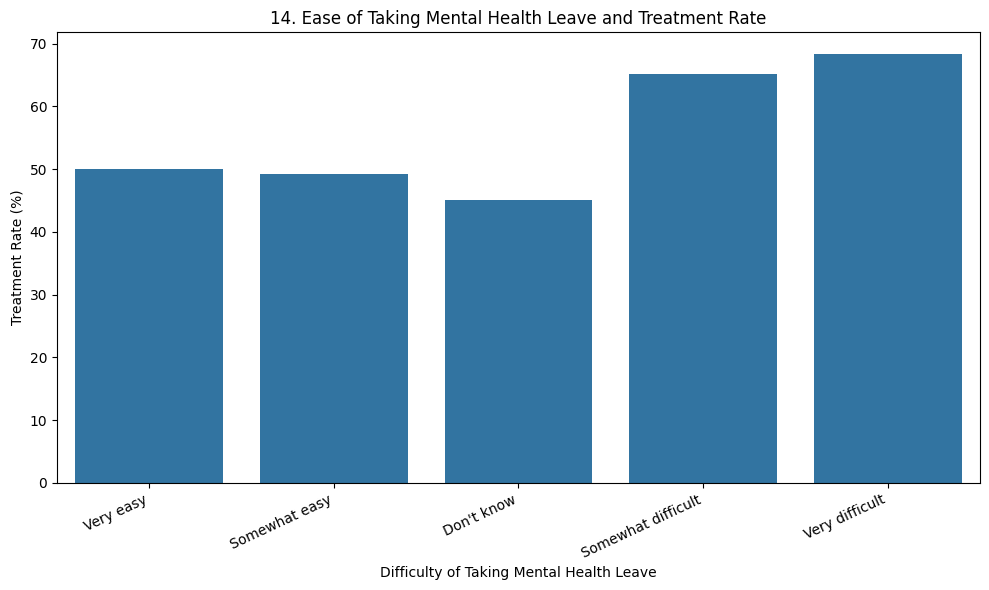

In [27]:
fig = plt.figure(figsize=(10,6))
leave_order = [
    'Very easy',
    'Somewhat easy',
    "Don't know",
    'Somewhat difficult',
    'Very difficult'
]
leave_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('leave', as_index=False)['Treatment_Rate'].mean()
leave_treatment['Treatment_Rate'] *= 100
sns.barplot(
    data=leave_treatment,
    x='leave',
    y='Treatment_Rate',
    order=leave_order
)
plt.title(f'{plot_no}. Ease of Taking Mental Health Leave and Treatment Rate')
plt.xlabel('Difficulty of Taking Mental Health Leave')
plt.ylabel('Treatment Rate (%)')
plt.xticks(rotation=25, ha='right')
show_fig()
plot_no += 1

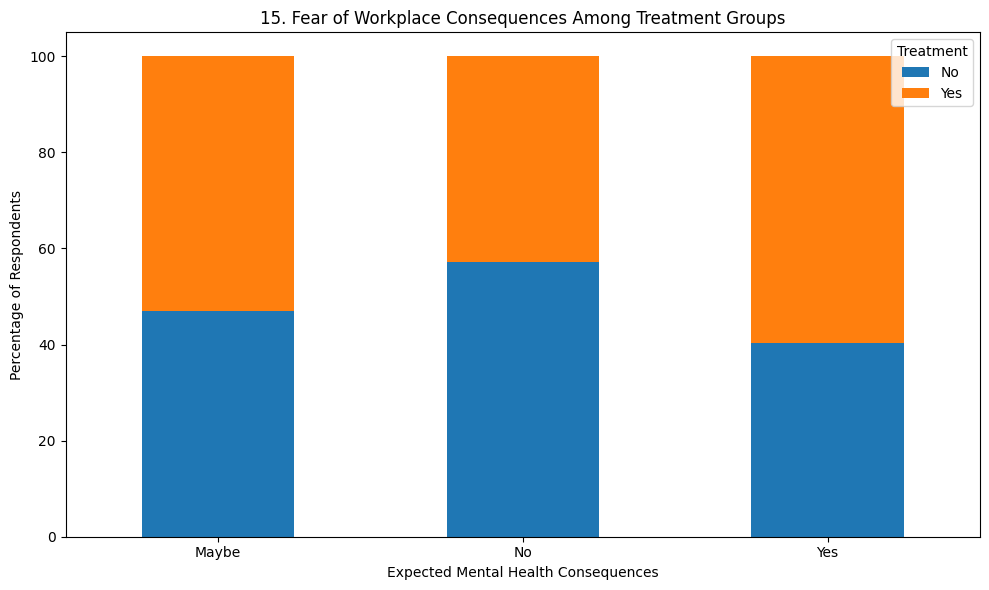

In [28]:
fig = plt.figure(figsize=(10,6))
consequence_treatment = pd.crosstab(
    df['mental_health_consequence'],
    df['treatment'],
    normalize='index'
).mul(100)
consequence_treatment.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Fear of Workplace Consequences Among Treatment Groups')
plt.xlabel('Expected Mental Health Consequences')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
show_fig()
plot_no += 1

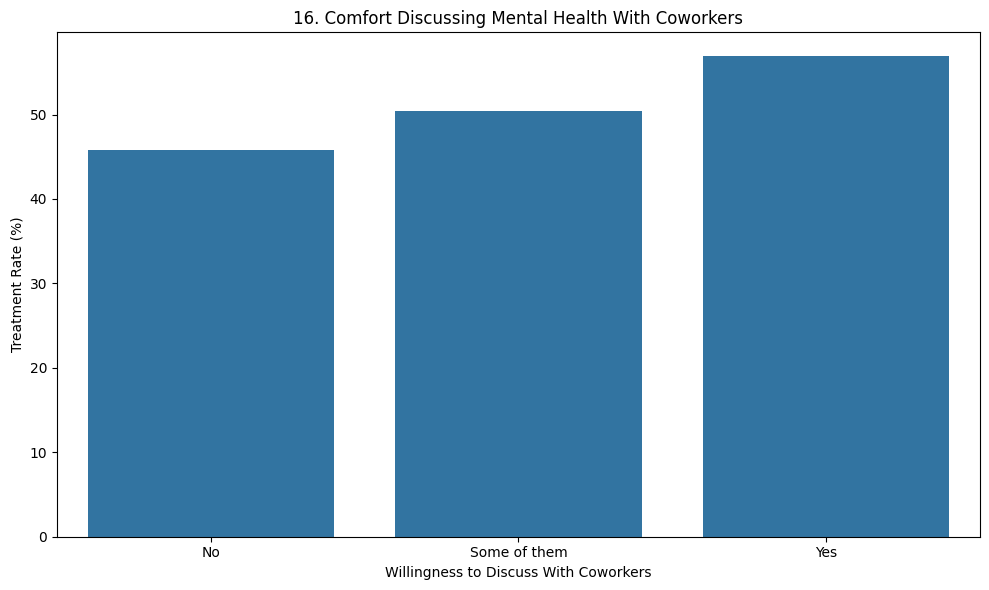

In [29]:
fig = plt.figure(figsize=(10,6))
coworker_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('coworkers', as_index=False)['Treatment_Rate'].mean()
coworker_treatment['Treatment_Rate'] *= 100
sns.barplot(data=coworker_treatment, x='coworkers', y='Treatment_Rate')
plt.title(f'{plot_no}. Comfort Discussing Mental Health With Coworkers')
plt.xlabel('Willingness to Discuss With Coworkers')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

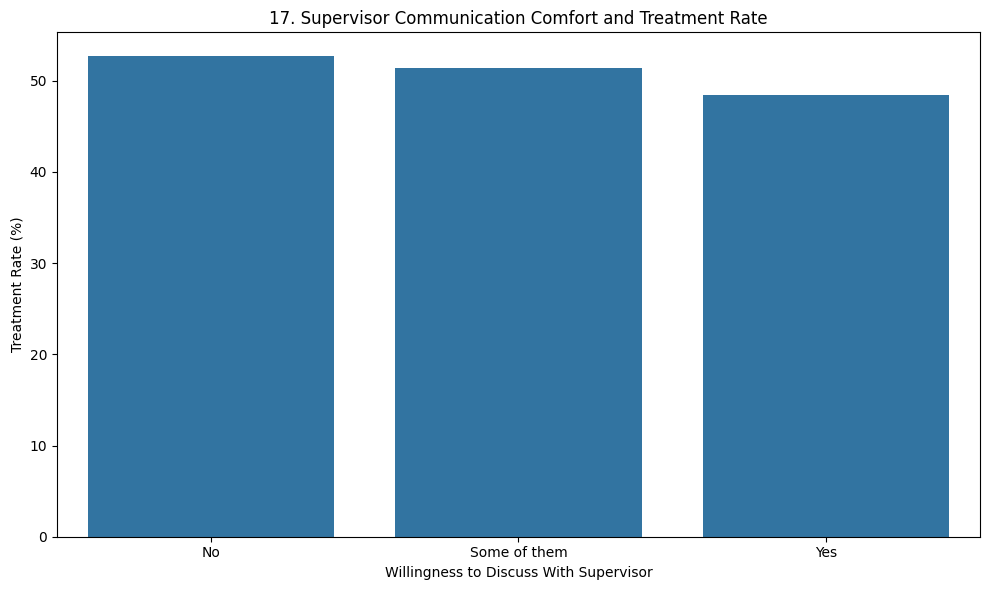

In [30]:
fig = plt.figure(figsize=(10,6))
supervisor_treatment = df.assign(
    Treatment_Rate=df['treatment'].eq('Yes').astype(int)
).groupby('supervisor', as_index=False)['Treatment_Rate'].mean()
supervisor_treatment['Treatment_Rate'] *= 100
sns.barplot(data=supervisor_treatment, x='supervisor', y='Treatment_Rate')
plt.title(f'{plot_no}. Supervisor Communication Comfort and Treatment Rate')
plt.xlabel('Willingness to Discuss With Supervisor')
plt.ylabel('Treatment Rate (%)')
show_fig()
plot_no += 1

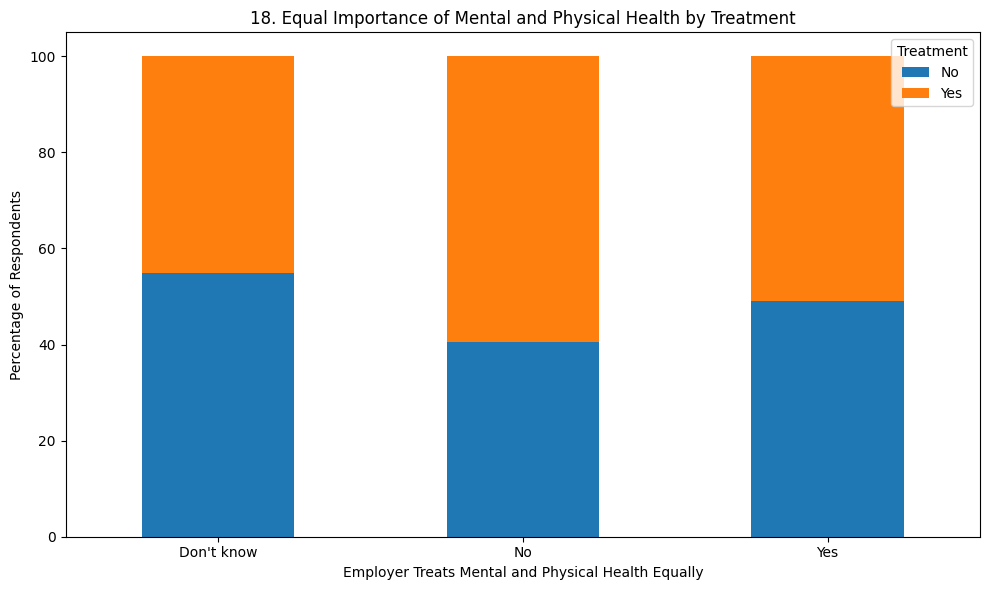

In [31]:
fig = plt.figure(figsize=(10,6))
priority_treatment = pd.crosstab(
    df['mental_vs_physical'],
    df['treatment'],
    normalize='index'
).mul(100)
priority_treatment.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(f'{plot_no}. Equal Importance of Mental and Physical Health by Treatment')
plt.xlabel('Employer Treats Mental and Physical Health Equally')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Treatment')
show_fig()
plot_no += 1

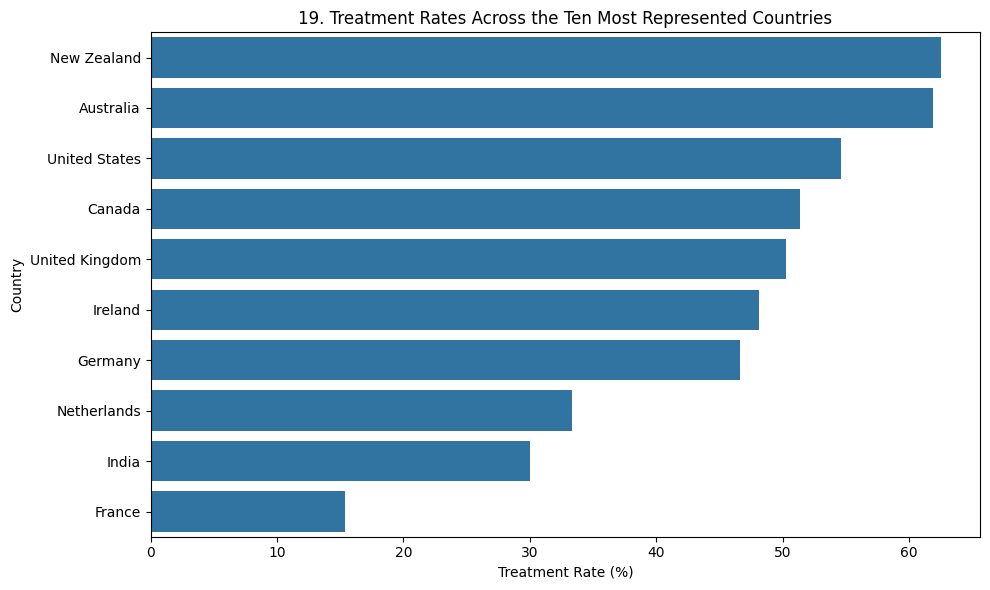

In [32]:
fig = plt.figure(figsize=(10,6))
country_counts = df['Country'].value_counts().head(10).index
country_treatment = df[df['Country'].isin(country_counts)].assign(
    Treatment_Rate=df[df['Country'].isin(country_counts)]['treatment'].eq('Yes').astype(int)
).groupby('Country', as_index=False)['Treatment_Rate'].mean()
country_treatment['Treatment_Rate'] *= 100
country_treatment = country_treatment.sort_values('Treatment_Rate', ascending=False)
sns.barplot(data=country_treatment, y='Country', x='Treatment_Rate')
plt.title(f'{plot_no}. Treatment Rates Across the Ten Most Represented Countries')
plt.xlabel('Treatment Rate (%)')
plt.ylabel('Country')
show_fig()
plot_no += 1

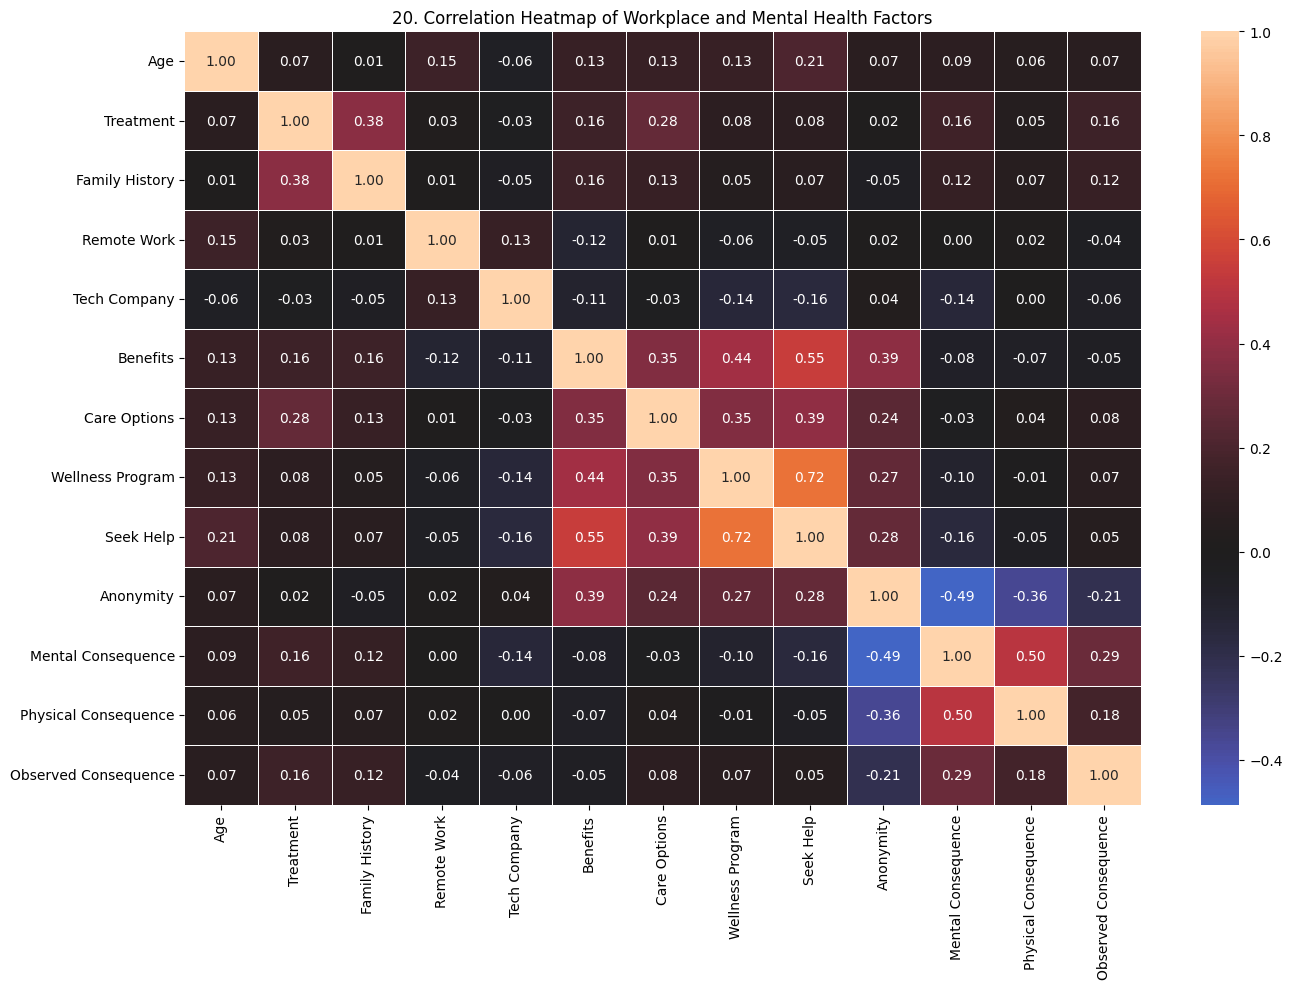

In [33]:
corr = pd.DataFrame({
    'Age': pd.to_numeric(df['Age'], errors='coerce').where(df['Age'].between(18, 75)),
    'Treatment': df['treatment'].map({'Yes': 1, 'No': 0}),
    'Family History': df['family_history'].map({'Yes': 1, 'No': 0}),
    'Remote Work': df['remote_work'].map({'Yes': 1, 'No': 0}),
    'Tech Company': df['tech_company'].map({'Yes': 1, 'No': 0}),
    'Benefits': df['benefits'].map({'Yes': 1, 'No': 0}),
    'Care Options': df['care_options'].map({'Yes': 1, 'No': 0}),
    'Wellness Program': df['wellness_program'].map({'Yes': 1, 'No': 0}),
    'Seek Help': df['seek_help'].map({'Yes': 1, 'No': 0}),
    'Anonymity': df['anonymity'].map({'Yes': 1, 'No': 0}),
    'Mental Consequence': df['mental_health_consequence'].map({'Yes': 1, 'No': 0}),
    'Physical Consequence': df['phys_health_consequence'].map({'Yes': 1, 'No': 0}),
    'Observed Consequence': df['obs_consequence'].map({'Yes': 1, 'No': 0})
}).corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', linewidths=0.5, center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Workplace and Mental Health Factors')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [35]:
data = df.copy()

## remove timestamp column if available

In [36]:
data = data.drop(columns=['Timestamp'], errors='ignore')

## remove invalid age values

In [37]:
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')
data = data[data['Age'].between(18, 75)]

## remove rows where target is missing

In [38]:
data = data.dropna(subset=['treatment'])

## separate input features and target column

In [39]:
X = data.drop(columns=['treatment'])
y = data['treatment']

## encode target labels

In [40]:
le = LabelEncoder()
y = le.fit_transform(y)

## detect numeric and categorical columns

In [41]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns

## create preprocessing steps

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## create supervised classification model

In [43]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

## split dataset into training and testing data

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## train model

In [45]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Country', 'family_history', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## predict test data

In [46]:
y_pred = model.predict(X_test)

## calculate accuracy score

In [47]:
accuracy = accuracy_score(y_test, y_pred)

## print model accuracy

In [48]:
print("Accuracy Score:", accuracy)

Accuracy Score: 0.7330677290836654


## print detailed classification report

In [49]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
               precision    recall  f1-score   support

          No       0.73      0.73      0.73       124
         Yes       0.73      0.74      0.74       127

    accuracy                           0.73       251
   macro avg       0.73      0.73      0.73       251
weighted avg       0.73      0.73      0.73       251



## create confusion matrix

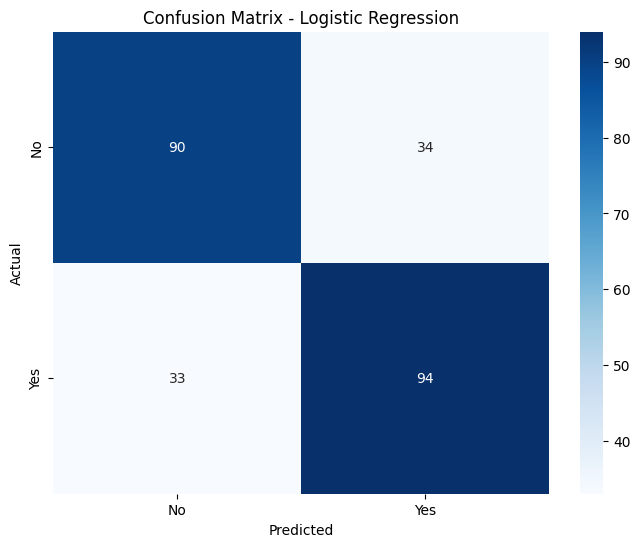

In [50]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()